In [1]:
print("I'm Anusha, building my second AI project!")

I'm Anusha, building my second AI project!


In [2]:
from sklearn.datasets import load_digits

digits = load_digits()

print("Dataset loaded successfully!")

Dataset loaded successfully!


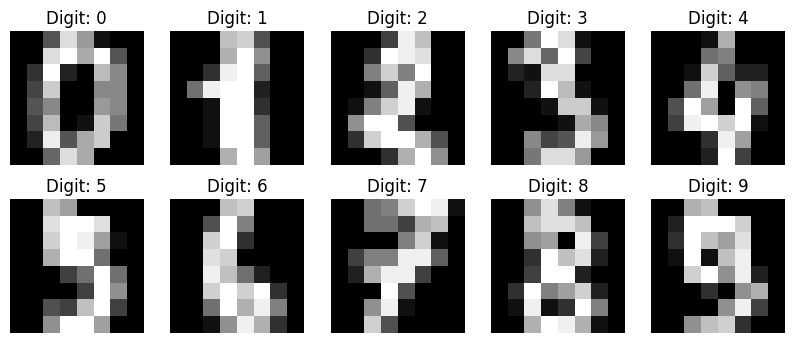

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(digits.images[i], cmap='gray')
    plt.title(f"Digit: {digits.target[i]}")
    plt.axis('off')

plt.show()

In [4]:
print("Number of images:", len(digits.images))
print("Image size:", digits.images[0].shape)
print("Number of labels:", len(digits.target))

Number of images: 1797
Image size: (8, 8)
Number of labels: 1797


In [5]:
X = digits.data
y = digits.target

print("Features shape:", X.shape)
print("Labels shape:", y.shape)

Features shape: (1797, 64)
Labels shape: (1797,)


In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 1437
Testing samples: 360


In [7]:
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(n_neighbors=3)

model.fit(X_train, y_train)

print("Model training completed!")

Model training completed!


In [8]:
y_pred = model.predict(X_test)

print("Predictions completed!")
print("First 20 predictions:", y_pred[:20])

Predictions completed!
First 20 predictions: [6 9 3 7 2 1 5 2 5 2 1 9 4 0 4 2 3 7 8 8]


In [9]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")

Accuracy: 0.9833333333333333
Accuracy Percentage: 98.33333333333333 %


In [10]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       0.97      1.00      0.98        28
           2       1.00      1.00      1.00        33
           3       0.97      1.00      0.99        34
           4       0.98      1.00      0.99        46
           5       0.98      0.98      0.98        47
           6       0.97      1.00      0.99        35
           7       1.00      0.97      0.99        34
           8       1.00      0.97      0.98        30
           9       0.97      0.93      0.95        40

    accuracy                           0.98       360
   macro avg       0.98      0.98      0.98       360
weighted avg       0.98      0.98      0.98       360



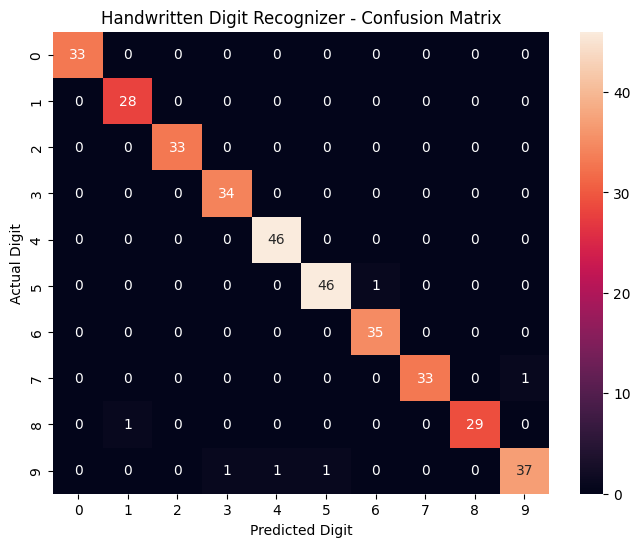

In [11]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=range(10),
    yticklabels=range(10)
)

plt.xlabel("Predicted Digit")
plt.ylabel("Actual Digit")
plt.title("Handwritten Digit Recognizer - Confusion Matrix")

plt.show()

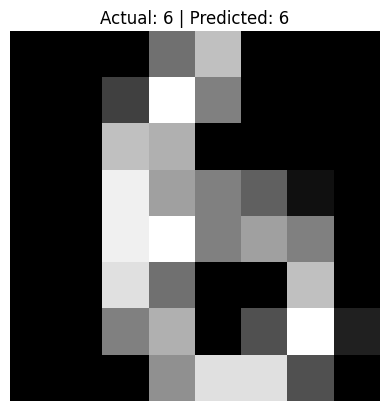

Actual Digit: 6
Predicted Digit: 6


In [12]:
import matplotlib.pyplot as plt

index = 0

image = X_test[index].reshape(8, 8)

actual_digit = y_test[index]
predicted_digit = model.predict([X_test[index]])[0]

plt.imshow(image, cmap='gray')
plt.title(f"Actual: {actual_digit} | Predicted: {predicted_digit}")
plt.axis('off')
plt.show()

print("Actual Digit:", actual_digit)
print("Predicted Digit:", predicted_digit)

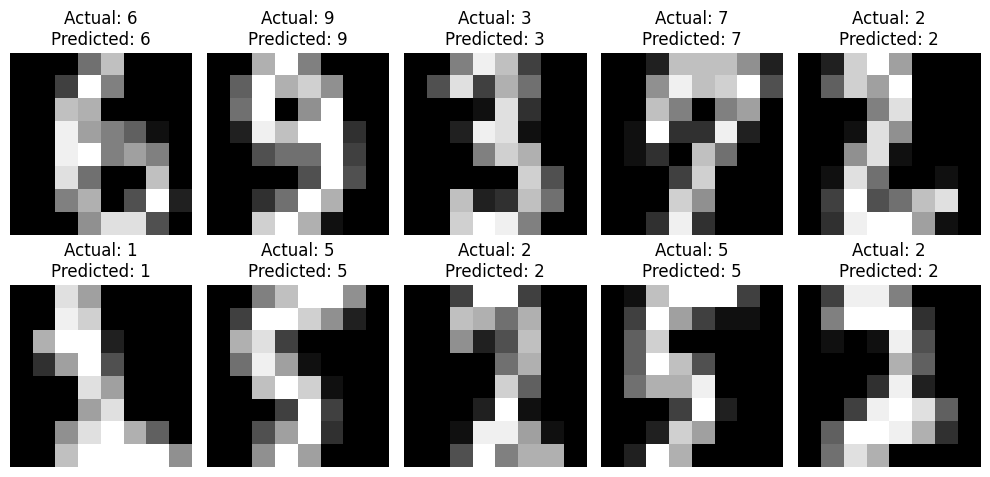

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

for i in range(10):
    image = X_test[i].reshape(8, 8)
    predicted_digit = model.predict([X_test[i]])[0]
    actual_digit = y_test[i]

    plt.subplot(2, 5, i + 1)
    plt.imshow(image, cmap='gray')
    plt.title(f"Actual: {actual_digit}\nPredicted: {predicted_digit}")
    plt.axis('off')

plt.tight_layout()
plt.show()

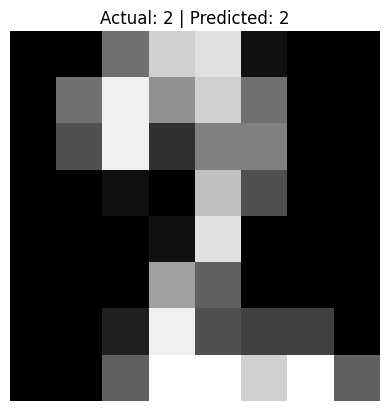

Actual Digit: 2
Predicted Digit: 2


In [15]:
import random
import matplotlib.pyplot as plt

index = random.randrange(len(X_test))

image = X_test[index].reshape(8, 8)
actual_digit = y_test[index]
predicted_digit = model.predict([X_test[index]])[0]

plt.imshow(image, cmap='gray')
plt.title(f"Actual: {actual_digit} | Predicted: {predicted_digit}")
plt.axis('off')
plt.show()

print("Actual Digit:", actual_digit)
print("Predicted Digit:", predicted_digit)

In [16]:
from IPython.display import display
import ipywidgets as widgets
from PIL import Image, ImageDraw
import numpy as np
import matplotlib.pyplot as plt

canvas = widgets.Image(
    value=b'',
    format='png',
    width=280,
    height=280
)

display(canvas)

Image(value=b'', height='280', width='280')

In [17]:
import ipywidgets as widgets
from IPython.display import display
from PIL import Image, ImageDraw
import numpy as np

# Create a black canvas
canvas = widgets.Image(
    value=b'',
    format='png',
    width=280,
    height=280
)

# Create a blank image
img = Image.new('L', (280, 280), 0)
draw = ImageDraw.Draw(img)

display(canvas)

print("Canvas created!")

Image(value=b'', height='280', width='280')

Canvas created!


In [18]:
from IPython.display import HTML, display

display(HTML("""
<canvas id="digitCanvas" width="280" height="280"
style="border:2px solid black; background:black; cursor:crosshair;">
</canvas>

<br><br>

<button onclick="clearCanvas()">Clear</button>

<script>
const canvas = document.getElementById("digitCanvas");
const ctx = canvas.getContext("2d");

ctx.fillStyle = "black";
ctx.fillRect(0, 0, canvas.width, canvas.height);

ctx.strokeStyle = "white";
ctx.lineWidth = 20;
ctx.lineCap = "round";

let drawing = false;

canvas.addEventListener("mousedown", () => drawing = true);
canvas.addEventListener("mouseup", () => {
    drawing = false;
    ctx.beginPath();
});
canvas.addEventListener("mousemove", draw);

function draw(event) {
    if (!drawing) return;

    const rect = canvas.getBoundingClientRect();

    const x = event.clientX - rect.left;
    const y = event.clientY - rect.top;

    ctx.lineTo(x, y);
    ctx.stroke();
    ctx.beginPath();
    ctx.moveTo(x, y);
}

function clearCanvas() {
    ctx.fillStyle = "black";
    ctx.fillRect(0, 0, canvas.width, canvas.height);
}
</script>
"""))

In [19]:
from IPython.display import HTML, display

display(HTML("""
<button onclick="sendDigit()"
style="font-size:18px; padding:10px 20px;">
Predict Digit
</button>

<script>
function sendDigit() {
    const canvas = document.getElementById("digitCanvas");

    const imageData = canvas.toDataURL("image/png");

    google.colab.kernel.invokeFunction(
        'notebook.get_image',
        [imageData],
        {}
    );
}
</script>
"""))

In [20]:
from google.colab import output
import base64
import io
from PIL import Image
import numpy as np

def get_image(data):
    # Remove the beginning part of the image data
    data = data.split(',')[1]

    # Convert image data into an image
    image_bytes = base64.b64decode(data)
    image = Image.open(io.BytesIO(image_bytes)).convert('L')

    # Convert to NumPy array
    image = np.array(image)

    print("Drawing received successfully!")
    print("Image size:", image.shape)

output.register_callback('notebook.get_image', get_image)

print("Python is connected to the drawing canvas!")

Python is connected to the drawing canvas!


In [21]:
from google.colab import output
import base64
import io
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

def get_image(data):
    # Remove the beginning part of the image data
    data = data.split(',')[1]

    # Convert image data into an image
    image_bytes = base64.b64decode(data)
    image = Image.open(io.BytesIO(image_bytes)).convert('L')

    # Convert to NumPy array
    image = np.array(image)

    # Resize to 8x8, like the training dataset
    image = Image.fromarray(image).resize((8, 8))

    # Convert back to NumPy array
    image = np.array(image)

    # Convert pixel values to the same range as the training data
    image = image / 255.0 * 16

    # Flatten 8x8 image into 64 values
    image_flat = image.reshape(1, 64)

    # Predict the digit
    prediction = model.predict(image_flat)[0]

    # Display the processed image
    plt.imshow(image, cmap='gray')
    plt.title(f"Predicted Digit: {prediction}")
    plt.axis('off')
    plt.show()

    print("🎯 Predicted Digit:", prediction)

output.register_callback('notebook.get_image', get_image)

print("AI Digit Recognizer is ready!")

AI Digit Recognizer is ready!


In [39]:
from IPython.display import HTML, display
from google.colab import output
import base64
import io
from PIL import Image
import numpy as np


def predict_digit(data):

    # Get image from canvas
    data = data.split(',')[1]
    image_bytes = base64.b64decode(data)

    # Open image
    image = Image.open(io.BytesIO(image_bytes)).convert('L')

    # Resize entire canvas directly to 8x8
    image = image.resize((8, 8), Image.Resampling.LANCZOS)

    # Convert to numpy array
    image = np.array(image)

    # Scale 0-255 to 0-16
    image = image / 255.0 * 16

    # Flatten
    image_flat = image.reshape(1, 64)

    # Predict
    prediction = int(model.predict(image_flat)[0])

    return prediction


# Register callback
output.register_callback(
    'notebook.predict_digit',
    predict_digit
)


display(HTML("""
<div style="text-align:center;">

<h2>✍️ Handwritten Digit Recognizer</h2>

<canvas id="digitCanvas"
        width="280"
        height="280"
        style="
        border:3px solid black;
        background:black;
        cursor:crosshair;">
</canvas>

<br><br>

<button onclick="clearCanvas()"
        style="
        font-size:18px;
        padding:10px 20px;">
Clear
</button>

<button onclick="predictDigit()"
        style="
        font-size:18px;
        padding:10px 20px;
        margin-left:10px;">
Predict Digit
</button>

<h2 id="prediction">
Draw a digit and click Predict Digit
</h2>

</div>


<script>

const canvas = document.getElementById("digitCanvas");
const ctx = canvas.getContext("2d");


// Black background
ctx.fillStyle = "black";
ctx.fillRect(0, 0, canvas.width, canvas.height);


// White brush
ctx.strokeStyle = "white";
ctx.lineWidth = 10;
ctx.lineCap = "round";
ctx.lineJoin = "round";

let drawing = false;


// Start drawing
canvas.addEventListener("mousedown", function(event) {

    drawing = true;

    const rect = canvas.getBoundingClientRect();

    const x = event.clientX - rect.left;
    const y = event.clientY - rect.top;

    ctx.beginPath();
    ctx.moveTo(x, y);
});


// Stop drawing
canvas.addEventListener("mouseup", function() {

    drawing = false;
    ctx.beginPath();

});


// Draw
canvas.addEventListener("mousemove", function(event) {

    if (!drawing) return;

    const rect = canvas.getBoundingClientRect();

    const x = event.clientX - rect.left;
    const y = event.clientY - rect.top;

    ctx.lineTo(x, y);
    ctx.stroke();

    ctx.beginPath();
    ctx.moveTo(x, y);

});


// Clear
function clearCanvas() {

    ctx.fillStyle = "black";
    ctx.fillRect(0, 0, canvas.width, canvas.height);

    document.getElementById("prediction").innerText =
        "Draw a digit and click Predict Digit";
}


// Predict
async function predictDigit() {

    document.getElementById("prediction").innerText =
        "Predicting...";

    const imageData = canvas.toDataURL("image/png");

    const result =
        await google.colab.kernel.invokeFunction(
            'notebook.predict_digit',
            [imageData],
            {}
        );

    let prediction = result.data;

    // Get actual prediction from Colab
    if (typeof prediction === "object" && prediction !== null) {
        prediction = prediction["text/plain"] || prediction;
    }

    prediction = String(prediction).replace(/['"]/g, "");

    document.getElementById("prediction").innerText =
        "Prediction: " + prediction;
}

</script>
"""))

print("Handwritten Digit Recognizer is ready!")

Handwritten Digit Recognizer is ready!


In [36]:
print("Model is working.")
print("Test prediction:", model.predict([X_test[0]])[0])

Model is working.
Test prediction: 6
